In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import mne
import entropy as ent
import neurokit2 as nk
from scipy.signal import welch
from nolds import lyap_r
import antropy as ant
import mne_features

In [2]:
import mne
import os

data_path = "../ds004504/derivatives"
boundary_subjects = []

for i in range(1, 89):  # 001 to 088 inclusive
    sub_id = f"sub-{i:03d}"
    eeg_path = os.path.join(data_path, sub_id, "eeg", f"{sub_id}_task-eyesclosed_eeg.set")
    
    if not os.path.exists(eeg_path):
        print(f"{sub_id} – file not found, skipping.")
        continue

    try:
        raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
        print(f"\n{sub_id}")
        print("All annotations:", list(raw.annotations.description))

        # Loop through all annotations and find 'boundary' events
        for onset, duration, desc in zip(raw.annotations.onset,
                                         raw.annotations.duration,
                                         raw.annotations.description):
            if 'boundary' in desc:
                print(f"  ➤ Boundary event at {onset:.2f}s lasting {duration:.2f}s ({desc})")
                if sub_id not in boundary_subjects:
                    boundary_subjects.append(sub_id)

    except Exception as e:
        print(f"{sub_id} – error loading file: {e}")

# Final summary
print("\n=== Subjects with 'boundary' events ===")
for sub in boundary_subjects:
    print(sub)



sub-001
All annotations: []

sub-002
All annotations: []

sub-003
All annotations: [np.str_('boundary')]
  ➤ Boundary event at 32.98s lasting 1.00s (boundary)


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)



sub-004
All annotations: [np.str_('boundary')]
  ➤ Boundary event at 479.74s lasting 1.00s (boundary)

sub-005
All annotations: []

sub-006
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 148.58s lasting 1.34s (boundary)
  ➤ Boundary event at 206.06s lasting 1.68s (boundary)
  ➤ Boundary event at 485.22s lasting 1.68s (boundary)


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)



sub-007
All annotations: [np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 32.64s lasting 1.00s (boundary)
  ➤ Boundary event at 314.86s lasting 1.68s (boundary)

sub-008
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 476.00s lasting 1.68s (boundary)
  ➤ Boundary event at 642.62s lasting 1.34s (boundary)
  ➤ Boundary event at 645.02s lasting 1.68s (boundary)
  ➤ Boundary event at 694.00s lasting 1.00s (boundary)

sub-009
All annotations: [np.str_('boundary')]
  ➤ Boundary event at 169.66s lasting 1.00s (boundary)


...

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)



sub-078
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 241.74s lasting 2.36s (boundary)
  ➤ Boundary event at 581.42s lasting 1.34s (boundary)
  ➤ Boundary event at 851.06s lasting 1.00s (boundary)

sub-079
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 25.16s lasting 1.68s (boundary)
  ➤ Boundary event at 113.92s lasting 1.34s (boundary)
  ➤ Boundary event at 533.84s lasting 1.00s (boundary)
  ➤ Boundary event at 554.94s lasting 2.02s (boundary)
  ➤ Boundary event at 800.10s lasting 1.68s (boundary)

sub-080
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 4.76s lasting 1.68s (boundary)
  ➤ Boundary event at 4.78s 

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)



sub-081
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 267.24s lasting 1.34s (boundary)
  ➤ Boundary event at 520.22s lasting 1.00s (boundary)
  ➤ Boundary event at 532.82s lasting 1.68s (boundary)
  ➤ Boundary event at 544.06s lasting 1.00s (boundary)

sub-082
All annotations: []

sub-083
All annotations: []

sub-084
All annotations: []

sub-085
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary')]
  ➤ Boundary event at 255.00s lasting 1.68s (boundary)
  ➤ Boundary event at 395.10s lasting 1.68s (boundary)
  ➤ Boundary event at 396.48s lasting 1.68s (boundary)
  ➤ Boundary event at 411.12s lasting 1.00s (boundary)

sub-086
All annotations: [np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('boundary'), np.str_('bound

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=True)
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2669705392.py:16: RuntimeWarning: The data c

In [3]:
participantsInfo = pd.read_table('../ds004504/participants.tsv')

In [4]:

raw_sub = mne.io.read_raw_eeglab('../ds004504/derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set', preload=True, verbose=True)
raw_sub.annotations

<Annotations | 0 segments>

In [5]:
raw_sub.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>

In [6]:
raw_sub.add_events

<bound method BaseRaw.add_events of <RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MB, data loaded>>

In [7]:
    sfreq = raw_sub.info['sfreq']
WINDOW_LENGTH = 3
STEP_SIZE = 1.5 #50% sliding window
start_times = np.arange(0, raw_sub.times[-1] - WINDOW_LENGTH, STEP_SIZE)
events = np.array([
        [int(t * sfreq), 0, 1] for t in start_times  # MNE event format
        ]) 

In [8]:
psd_sub = raw_sub.compute_psd(method='welch', fmin=0.5, fmax=30)

Effective window size : 4.096 (s)


Plotting power spectral density (dB=True).


/Volumes/CrucialX6/Home/neuro-venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


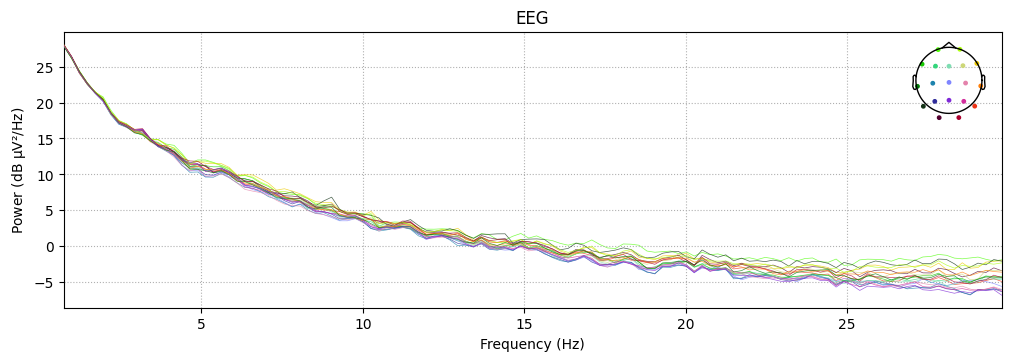

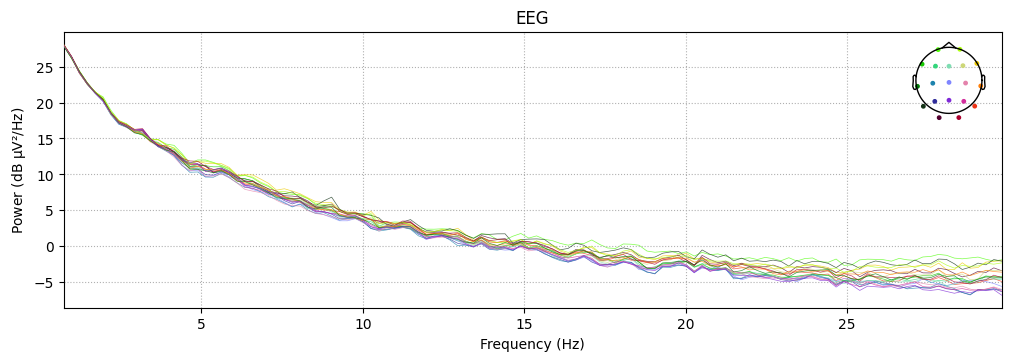

In [9]:
psd_sub.plot()

In [10]:
raw_sub003 = mne.io.read_raw_eeglab('../ds004504/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set', preload=True, verbose=True)

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_25322/2430713568.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub003 = mne.io.read_raw_eeglab('../ds004504/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set', preload=True, verbose=True)


In [11]:
start_times = np.arange(0, raw_sub003.times[-1] - WINDOW_LENGTH, STEP_SIZE)
sfreq = raw_sub003.info['sfreq']
events = np.array([
        [int(t * sfreq), 0, 1] for t in start_times  # MNE event format
        ]) 

epochs = mne.Epochs(
    raw_sub003, events, event_id=1,
    tmin=0, tmax=WINDOW_LENGTH,
    baseline=None, detrend=1, preload=True, verbose=False,
)
print(len(epochs))

203


In [12]:
for i, desc in enumerate(raw_sub003.annotations.description):
    if 'boundary' in desc:
        raw_sub003.annotations.description[i] = 'BAD_boundary'

epochs = mne.Epochs(
    raw_sub003, events, event_id=1,
    tmin=0, tmax=WINDOW_LENGTH,
    baseline=None, detrend=1, preload=True, verbose=False,
    reject_by_annotation=True
)

len(epochs)

200

In [13]:
epoch = epochs[0]

In [14]:
epoch.data

AttributeError: 'Epochs' object has no attribute 'data'

In [ ]:
epoch_psd = epoch.compute_psd(method='welch', fmin=freq_bands["Delta"][0], fmax=freq_bands["Beta"][1], verbose=True) #computing the max PSD between the wave lengths

In [ ]:
# data = epoch_psd.get_data(picks='eeg')[0]
data, freqs = epoch_psd.get_data(return_freqs=True)
data = data[0]
print(data.shape)
print(data[0])
print(freqs.shape)

# Testing data functions 

In [ ]:
from mne_features.univariate import (
    compute_app_entropy,
    compute_samp_entropy,
    compute_higuchi_fd,
    compute_katz_fd,
    compute_hjorth_mobility,
    compute_hjorth_complexity,
    compute_rms,
    compute_skewness,
    compute_kurtosis,
    compute_std,
    compute_mean
)

In [ ]:
channelNames = epoch.info['ch_names']
freqBands = {
  'Alpha': [8, 12],
  'Beta': [12, 30],
  'Delta': [0.5, 4],
  'Theta': [4, 8],
  'custom1': [9, 11]
}

In [ ]:
for channel_idx, channel_name in enumerate(channelNames):
    for band_name, (band_fmin, band_fmax) in freqBands.items():
        band_mask = (
        band_data = data[channel_idx][
        


In [ ]:
sfreq

In [15]:
import sys
import os

# Add ../src to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

# Now import your function
from feature_extraction import processEpoch


Config not found in feature_extraction.py
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}


In [16]:
%%time
# processEpoch(subjectID, epochID, epoch, freqBands=freqBands, method=method, windowLength=windowLength, stepSize=stepSize, n_jobs=1):
# there are 178828 epochs
method = 'welch'
windowLength = 3
stepSize = 1.5
channelNames = epoch.info['ch_names']
freqBands = {
  'Alpha': [8, 12],
  'Beta': [12, 30],
  'Delta': [0.5, 4],
  'Theta': [4, 8],
  'custom1': [9, 11]
}
results_new = processEpoch("sub-003", "Ep-001", epoch, freqBands=freqBands, method='welch', windowLength = 3, stepSize=1.5, n_jobs=1)

CPU times: user 2.43 s, sys: 266 ms, total: 2.7 s
Wall time: 2.78 s


In [17]:
import pandas as pd
df = pd.DataFrame(results_new)
display(df)

,0,1,2,3,4,5,6
0,sub-003,Ep-001,Fp1,None,TotalPower,1.123596e-02,electrode
1,sub-003,Ep-001,Fp1,None,TotalEnergy,1.078183e-01,electrode
2,sub-003,Ep-001,Fp1,None,SpectralEntropy,4.174008e+00,electrode
3,sub-003,Ep-001,Fp1,None,HjorthActivity,9.705875e-10,electrode
4,sub-003,Ep-001,Fp1,None,HjorthMobility,4.557605e-02,electrode
...,...,...,...,...,...,...,...
616,sub-003,Ep-001,None,None,HjorthIndex,1.113702e+03,epoch
617,sub-003,Ep-001,None,None,AppEntropy,1.468064e-01,epoch
618,sub-003,Ep-001,None,None,SampleEntropy,1.335114e-03,epoch
619,sub-003,Ep-001,None,None,HiguchiFD,1.101798e+00,epoch


In [141]:
%%time
# from eeg_feature_extraction import *

results = []

for channel_idx, channel_name in enumerate(channelNames):
    for band_name, (fmin, fmax) in freqBands.items():
        band_mask = (freqs >= fmin) & (freqs < fmax)

        # From precomputed PSD
        psd_band = data[channel_idx, band_mask]
        spectral_entropy = spectral_entropy_from_psd(psd_band)
        total_power = total_band_power(data, channel_idx)

        # Replace with real band-pass filtered time-domain signal
        time_signal = np.random.randn(1, 500)  # shape (1, n_times), axis=1 is time

        # Basic stats
        mean_val = compute_mean(time_signal)[0]
        std_val = compute_std(time_signal)[0]
        var_val = compute_variance(time_signal)[0]
        rms_val = compute_rms(time_signal)[0]

        # Higher-order stats
        skew_val = compute_skewness(time_signal)[0]
        kurt_val = compute_kurtosis(time_signal)[0]

        # Hjorth
        mobility = compute_hjorth_mobility(time_signal)[0]
        complexity = compute_hjorth_complexity(time_signal)[0]
        activity = var_val  # Hjorth activity = variance
        hjorth_idx = compute_hjorth_index(time_signal)[0]

        # Entropy & nonlinear
        app_entropy = compute_app_entropy(time_signal)[0]
        samp_entropy = compute_samp_entropy(time_signal)[0]

        # Fractal dimensions
        higuchi = compute_higuchi_fd(time_signal)[0]
        katz = compute_katz_fd(time_signal)[0]

        # Append all
        results.append({
            'channel': channel_name,
            'band': band_name,
            'mean': mean_val,
            'std': std_val,
            'variance': var_val,
            'rms': rms_val,
            'skewness': skew_val,
            'kurtosis': kurt_val,
            'hjorth_activity': activity,
            'hjorth_mobility': mobility,
            'hjorth_complexity': complexity,
            'hjorth_index': hjorth_idx,
            'spectral_entropy': spectral_entropy,
            'approx_entropy': app_entropy,
            'sample_entropy': samp_entropy,
            'higuchi_fd': higuchi,
            'katz_fd': katz,
            'total_band_power': total_power
        })



CPU times: user 1.72 s, sys: 8.43 ms, total: 1.73 s
Wall time: 1.73 s


In [164]:
method = 'welch'
windowLength = 3
stepSize = 1.5
from mne.filter import filter_data

from pyspark.sql import Row
def processEpoch(subjectID, epochID, epoch, freqBands=freqBands, method=method, windowLength=windowLength, stepSize=stepSize, n_jobs=1):
    fmin = min(band_range[0] for band_range in freqBands.values())
    fmax = max(band_range[1] for band_range in freqBands.values())

    channelNames = epoch.info['ch_names']

    # PSD-based features
    psds, freqs = epoch.compute_psd(
        method=method,
        picks='eeg',
        fmin=fmin,
        fmax=fmax,
        verbose=False
    ).get_data(return_freqs=True)
    
    normalPsds = psds / np.sum(psds, axis=-1, keepdims=True)
    normalPsds = np.squeeze(normalPsds)

    # Time-domain EEG data for this epoch
    data = epoch.get_data(picks="eeg")[0]  # shape (n_channels, n_times)

    rows = []

    for channel_idx, channel_name in enumerate(channelNames):
        # Electrode-level features (non-band-specific)
        # electrode_features = [
        #     ("TotalPower", totalBandPower(normalPsds, freqs, channel_idx)),
        #     ("TotalEnergy", totalEnergy(normalPsds, freqs, channel_idx)),
        #     ("SpectralEntropy", spectral_entropy_from_psd(normalPsds[channel_idx, :])),
        #     ("HjorthActivity", np.var(data[channel_idx, :])),
        #     ("HjorthMobility", compute_hjorth_mobility(data[channel_idx:channel_idx+1])[0]),
        #     ("HjorthComplexity", compute_hjorth_complexity(data[channel_idx:channel_idx+1])[0]),
        #     ("HjorthIndex", compute_hjorth_index(data[channel_idx:channel_idx+1])[0])
        # ]
        
        # for fname, val in electrode_features:
        #     rows.append(Row(
        #         SubjectID=subjectID,
        #         EpochID=epochID,
        #         Electrode=channel_name,
        #         WaveBand=None,
        #         FeatureName=fname,
        #         FeatureValue=float(val),
        #         table_type="electrode"
        #     ))


        for band_name, (band_fmin, band_fmax) in freqBands.items():
            band_mask = (freqs >= band_fmin) & (freqs < band_fmax)
            psd_band = normalPsds[channel_idx, band_mask]
        
            # --- PSD-based Features ---
            band_power = psd_band.mean()
            spectral_entropy = spectral_entropy_from_psd(psd_band)
        
            # --- Time-domain features (needs bandpass!) ---
            band_transitions = {
            "Delta": (0.25, 1.0),
            "Theta": (1.0, 1.0),
            "Alpha": (1.0, 1.0),
            "Beta": (2.0, 2.0),
            "custom1": (0.5, 0.5)
            }
        
            l_bw, h_bw = band_transitions[band_name]
        
            band_signal = filter_data(
                data[channel_idx, :],
                sfreq=epoch.info["sfreq"],
                l_freq=band_fmin,
                h_freq=band_fmax,
                l_trans_bandwidth=l_bw,
                h_trans_bandwidth=h_bw,
                fir_design="firwin",
                verbose=False
            )
            
            band_features = [
                ("Power", band_power),
                ("SpectralEntropy", spectral_entropy),
                ("Mean", np.mean(band_signal)),
                ("Std", np.std(band_signal)),
                ("Variance", np.var(band_signal)),
                ("Skewness", compute_skewness(band_signal[np.newaxis, :])[0]),
                ("Kurtosis", compute_kurtosis(band_signal[np.newaxis, :])[0]),
                ("RMS", compute_rms(band_signal[np.newaxis, :])[0]),
                ("HjorthMobility", compute_hjorth_mobility(band_signal[np.newaxis, :])[0]),
                ("HjorthComplexity", compute_hjorth_complexity(band_signal[np.newaxis, :])[0]),
                ("HjorthIndex", compute_hjorth_index(band_signal[np.newaxis, :])[0]),
                ("AppEntropy", compute_app_entropy(band_signal[np.newaxis, :])[0]),
                ("SampleEntropy", compute_samp_entropy(band_signal[np.newaxis, :])[0]),
                ("HiguchiFD", compute_higuchi_fd(band_signal[np.newaxis, :])[0]),
                ("KatzFD", compute_katz_fd(band_signal[np.newaxis, :])[0])
            ]
        
            for fname, val in band_features:
                rows.append(Row(
                    SubjectID=subjectID,
                    EpochID=epochID,
                    Electrode=channel_name,
                    WaveBand=band_name,
                    FeatureName=fname,
                    FeatureValue=float(val),
                    table_type="band"
                ))



    # Epoch-level features: averaged across all channels
    # epoch_feature_list = [
    #     ("Mean", np.mean(compute_mean(data))),
    #     ("Std", np.mean(compute_std(data))),
    #     ("Variance", np.mean(compute_variance(data))),
    #     ("Skewness", np.mean(compute_skewness(data))),
    #     ("Kurtosis", np.mean(compute_kurtosis(data))),
    #     ("RMS", np.mean(compute_rms(data))),
    #     ("HjorthMobility", np.mean(compute_hjorth_mobility(data))),
    #     ("HjorthComplexity", np.mean(compute_hjorth_complexity(data))),
    #     ("HjorthIndex", np.mean(compute_hjorth_index(data))),
    #     ("AppEntropy", np.mean(compute_app_entropy(data))),
    #     ("SampleEntropy", np.mean(compute_samp_entropy(data))),
    #     ("HiguchiFD", np.mean(compute_higuchi_fd(data))),
    #     ("KatzFD", np.mean(compute_katz_fd(data)))
    # ]
    
    # for fname, val in epoch_feature_list:
    #     rows.append(Row(
    #         SubjectID=subjectID,
    #         EpochID=epochID,
    #         Electrode=None,
    #         WaveBand=None,
    #         FeatureName=fname,
    #         FeatureValue=float(val),
    #         table_type="epoch"
    # ))
        
    return rows


In [165]:
%%time
# processEpoch(subjectID, epochID, epoch, freqBands=freqBands, method=method, windowLength=windowLength, stepSize=stepSize, n_jobs=1):
# there are 178828 epochs
results_new = processEpoch("sub-003", "Ep-001", epoch, freqBands=freqBands, method='welch', windowLength = 3, stepSize=1.5, n_jobs=1)

/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_99399/691572569.py:73: RuntimeWarning: filter_length (1651) is longer than the signal (1501), distortion is likely. Reduce filter length or filter a longer signal.
  band_signal = filter_data(
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_99399/691572569.py:73: RuntimeWarning: filter_length (6601) is longer than the signal (1501), distortion is likely. Reduce filter length or filter a longer signal.
  band_signal = filter_data(
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_99399/691572569.py:73: RuntimeWarning: filter_length (1651) is longer than the signal (1501), distortion is likely. Reduce filter length or filter a longer signal.
  band_signal = filter_data(
/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_99399/691572569.py:73: RuntimeWarning: filter_length (3301) is longer than the signal (1501), distortion is likely. Reduce filter length or filter a longer signal.
  band_signal = filte

CPU times: user 12.1 s, sys: 1.96 s, total: 14 s
Wall time: 14 s


/var/folders/l1/yg4p3qp10vq4pn5lyx21tcdr0000gq/T/ipykernel_99399/691572569.py:73: RuntimeWarning: filter_length (3301) is longer than the signal (1501), distortion is likely. Reduce filter length or filter a longer signal.
  band_signal = filter_data(


In [166]:
import pandas as pd
df = pd.DataFrame(results_new)
display(df)

,0,1,2,3,4,5,6
0,sub-003,Ep-001,Fp1,Alpha,Power,8.017267e-03,band
1,sub-003,Ep-001,Fp1,Alpha,SpectralEntropy,2.266552e+00,band
2,sub-003,Ep-001,Fp1,Alpha,Mean,-7.465286e-08,band
3,sub-003,Ep-001,Fp1,Alpha,Std,6.508632e-06,band
4,sub-003,Ep-001,Fp1,Alpha,Variance,4.236229e-11,band
...,...,...,...,...,...,...,...
1420,sub-003,Ep-001,Pz,custom1,HjorthIndex,4.192478e+02,band
1421,sub-003,Ep-001,Pz,custom1,AppEntropy,4.694401e-01,band
1422,sub-003,Ep-001,Pz,custom1,SampleEntropy,1.335114e-03,band
1423,sub-003,Ep-001,Pz,custom1,HiguchiFD,1.025856e+00,band


In [134]:
import pandas as pd
df = pd.DataFrame(results_new)
display(df)

,0,1,2,3,4,5,6
0,sub-003,Ep-001,Fp1,Alpha,Power,0.008017,band
1,sub-003,Ep-001,Fp1,Beta,Power,0.000874,band
2,sub-003,Ep-001,Fp1,Delta,Power,0.060341,band
3,sub-003,Ep-001,Fp1,Theta,Power,0.016069,band
4,sub-003,Ep-001,Fp1,custom1,Power,0.002884,band
...,...,...,...,...,...,...,...
140,sub-003,Ep-001,None,None,HjorthComplexity,12.377305,epoch
141,sub-003,Ep-001,None,None,AppEntropy,0.160882,epoch
142,sub-003,Ep-001,None,None,SampleEntropy,0.146841,epoch
143,sub-003,Ep-001,None,None,HiguchiFD,1.101798,epoch


In [123]:
import pandas as pd
df = pd.DataFrame(results)
display(df)


,channel,band,mean,std,variance,rms,skewness,kurtosis,hjorth_activity,hjorth_mobility,hjorth_complexity,hjorth_index,spectral_entropy,approx_entropy,sample_entropy,higuchi_fd,katz_fd,total_band_power
0,Fp1,Alpha,0.034833,0.978325,0.957121,0.978945,0.028082,0.029792,0.957121,1.380556,1.240249,38.697791,2.266552,2.137758,0.004024,2.012919,0.551253,9.602024e-12
1,Fp1,Beta,0.034760,1.022905,1.046334,1.023495,0.055224,0.079958,1.046334,1.431469,1.216676,37.362505,4.968076,2.189616,0.004024,2.014246,0.563768,9.602024e-12
2,Fp1,Delta,0.020517,0.990913,0.981909,0.991126,0.039294,0.103553,0.981909,1.397176,1.229046,38.244573,2.540524,2.288157,0.004024,1.993034,0.553210,9.602024e-12
3,Fp1,Theta,-0.097240,0.946870,0.896563,0.951850,0.126888,0.255082,0.896563,1.426739,1.208165,37.461294,3.380340,2.183001,0.004024,2.020600,0.578351,9.602024e-12
4,Fp1,custom1,-0.013250,1.031560,1.064116,1.031645,0.018347,0.134254,1.064116,1.405856,1.232269,38.030046,2.338403,2.122623,0.004024,2.012100,0.546533,9.602024e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Pz,Alpha,-0.011092,1.018058,1.036441,1.018118,0.004996,-0.439076,1.036441,1.427213,1.209530,37.452380,2.531998,2.191145,0.004024,2.009229,0.545954,1.043349e-11
91,Pz,Beta,-0.001001,0.961389,0.924270,0.961390,-0.124194,-0.252857,0.924270,1.384542,1.230676,38.574365,4.877827,2.206133,0.004024,1.995182,0.555399,1.043349e-11
92,Pz,Delta,0.023285,0.972734,0.946211,0.973012,-0.027206,0.116131,0.946211,1.362712,1.262469,39.216484,2.938051,2.177485,0.004024,2.004626,0.553402,1.043349e-11
93,Pz,Theta,-0.044171,0.974540,0.949729,0.975541,0.157810,-0.374471,0.949729,1.409366,1.215232,37.907409,3.385871,2.249286,0.004024,2.012685,0.546808,1.043349e-11


# Pyspark get subject 1 

In [76]:
# ** This cell is needed since we are not in the src directory 
import sys 
import os
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

import sys
sys.path.append("/Users/admin/eeg-ds004504/")


In [77]:
from config_handler import initiate_config, load_config

In [78]:
initiate_config()

{'data_path': '/Users/admin/eeg-ds004504',
 'derivatives': True,
 'freqBands': {'Alpha': [8, 12],
  'Beta': [12, 30],
  'Delta': [0.5, 4],
  'Theta': [4, 8],
  'custom1': [9, 11]},
 'method': 'welch',
 'stepSize': 0.3,
 'windowLength': 3}

In [79]:
print(load_config())

{'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}


In [80]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd

In [81]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [82]:
import os
from pyspark.sql import SparkSession

# Set Java options for the JVM running Spark
# -Xmx12g : Sets the maximum heap size to 12GB
# -Xms4g : Sets the initial heap size to 4GB to avoid resizing overhead
os.environ["_JAVA_OPTIONS"] = "-Xmx12g -Xms4g"

# Build Spark session with memory, parallelism, and network settings
spark = (
    SparkSession.builder 
    # Application name shown in Spark UI
    .appName("EEG_Analysis") 

    # Use all available logical cores or specify a number
    # "local[*]" uses all available cores, "local[12]" limits to 12 threads
    .config("spark.master", "local[12]") \

    # Executor memory: how much memory each Spark worker can use
    .config("spark.executor.memory", "8g") \

    # Driver memory: memory available to the Spark driver (main Python process)
    .config("spark.driver.memory", "8g") \

    # Number of shuffle partitions (e.g., after groupBy, join, etc.)
    # Lower this in local mode to reduce overhead (default is 200)
    .config("spark.sql.shuffle.partitions", "12") \

    # Default number of partitions in operations like parallelize
    .config("spark.default.parallelism", "12") \

    # Maximum size (in MB) allowed for any RPC message (e.g., large UDF closures or data broadcasts)
    .config("spark.rpc.message.maxSize", "256") \

    # Required for avoiding binding issues on some MacOS environments
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") 
    .getOrCreate()
)

    # ----------------------------------------
    # Additional advanced options (optional):
    # ----------------------------------------

    # Use Kryo serializer instead of default Java serializer for better performance
    # .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \

    # Increase broadcast join timeout (in seconds) for large models or lookup tables
    # .config("spark.sql.broadcastTimeout", "600") \

    # Fraction of JVM memory reserved for execution and storage (default is 0.6)
    # .config("spark.memory.fraction", "0.8") \

    # Portion of memory reserved for caching/storage (default is 0.5 of memory.fraction)
    # .config("spark.memory.storageFraction", "0.3") \

    # Enable Apache Arrow for efficient pandas-to-Spark conversion (useful with UDFs)
    # .config("spark.sql.execution.arrow.pyspark.enabled", "true") \

    # Finalize and create the Spark session


# spark = SparkSession.builder.appName("MyApp").getOrCreate()

print("New Spark session created successfully")

Picked up _JAVA_OPTIONS: -Xmx12g -Xms4g
Picked up _JAVA_OPTIONS: -Xmx12g -Xms4g
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/23 18:17:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/23 18:17:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/23 18:17:06 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/04/23 18:17:06 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


New Spark session created successfully


In [83]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema

sc = spark.sparkContext # we pass udf/udtf's (user defind functions and user defined table functions) to spark so it can access them

# Making all necessary modules available to spark
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "config_handler.py"))
    print("Added config_handler.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Config not found in feature_extraction.py
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context
Added config_handler.py to the pyspark context


In [84]:
subject_df = load_subjects_df(spark) #this is the .tsv with the information of all the participants

In [85]:
# creating table for sub1 then saving it as a .pkl

In [86]:
%%time
# we need to give the path of our  data directory to process the EEG data from
from preprocess_sets import get_data_path

# set_data_path("/Users/user/eeg-ds004504") !!! this doesn't work! so we need to do it manually in preprocess_sets.py! or else won't work!
print(get_data_path())

#Example below is how to get a single subject  and extract its features
sub1 = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
print("3 tables types")
sub1.filter((sub1.table_type=="band")).show(3)
sub1.filter((sub1.table_type=="electrode")).show(3)
sub1.filter((sub1.table_type=="epoch")).show(3)

/Users/admin/eeg-ds004504
3 tables types


/Volumes/CrucialX6/Home/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
Config not found in feature_extraction.py                           (0 + 1) / 1]
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
processSub sub-001
processSub: derivatives True
processSub: windowLength 3
processSub: windowLength 0.3
subPath sub-001
subPath data_path /Users/admin/eeg-ds004504
Derivatives: True
Derivatives from config: True
Path handed: /Users/admin/eeg-ds004504/ds004504/derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
ERROR:root:KeyboardInterrupt while sending command.
Traceback (most r

KeyboardInterrupt: 

[Stage 2:>                                                          (0 + 1) / 1]

In [12]:
sub1.printSchema()

root
 |-- SubjectID: string (nullable = false)
 |-- EpochID: string (nullable = false)
 |-- Electrode: string (nullable = true)
 |-- WaveBand: string (nullable = true)
 |-- FeatureName: string (nullable = true)
 |-- FeatureValue: float (nullable = true)
 |-- table_type: string (nullable = true)



In [13]:
sub1.show()

Config not found in feature_extraction.py                           (0 + 1) / 1]
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
processSub sub-001
subPath sub-001
subPath data_path /Users/admin/eeg-ds004504
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
[Stage 11:>                                                         (0 + 1) / 1]

+---------+-------+---------+--------+-----------+------------+----------+
|SubjectID|EpochID|Electrode|WaveBand|FeatureName|FeatureValue|table_type|
+---------+-------+---------+--------+-----------+------------+----------+
|  sub-001|   ep-0|      Fp1|   Alpha|      Power|0.0011432203|      band|
|  sub-001|   ep-0|      Fp1|    Beta|      Power|1.9580401E-4|      band|
|  sub-001|   ep-0|      Fp1|   Delta|      Power|  0.08257893|      band|
|  sub-001|   ep-0|      Fp1|   Theta|      Power|0.0056116455|      band|
|  sub-001|   ep-0|      Fp1| custom1|      Power|0.0010104624|      band|
|  sub-001|   ep-0|      Fp1|    NULL|TotalEnergy|  0.24224812| electrode|
|  sub-001|   ep-0|      Fp1|    NULL| TotalPower| 0.011235955| electrode|
|  sub-001|   ep-0|      Fp2|   Alpha|      Power| 9.638189E-4|      band|
|  sub-001|   ep-0|      Fp2|    Beta|      Power|1.7688205E-4|      band|
|  sub-001|   ep-0|      Fp2|   Delta|      Power| 0.083892204|      band|
|  sub-001|   ep-0|      

In [ ]:
# from datetime import import datetime
# import os
# from config_handler import load_config

# def create_database_log(df, filename, config, timestamp):
#     """
#     Creates a log file with information about the saved dataframe.
    
#     Parameters:
#     - df: The Spark DataFrame being saved
#     - filename: The name of the saved pkl file
#     - config: Configuration dictionary from load_config()
#     """
#     # Count unique subjects
#     try:
#         unique_subjects = df.select("SubjectID").distinct().count()
#     except:
#         unique_subjects = -1
    
#     # Create log entry
#     log_entry = [
#         f"=== DATABASE LOG ENTRY: {timestamp} ===",
#         f"Saved file: {filename}",
#         f"Unique subjects: {unique_subjects}",
#         "\nConfiguration:",
#     ]
    
#     # Write to log file
#     with open("databaselog.txt", "a") as f:
#         f.write("\n".join(log_entry))
    
#     print(f"Log entry written to databaselog.txt")

In [ ]:
# from datetime import import datetime

# # Generate a timestamp like "Apr14_2230"
# timestamp = datetime.now().strftime("%b%d_%H%M")
# # **** I THINK SHOULD PIVOT for all 3 tables, GROUP BY SUBJECTID, EPOCHID and then save so that the new one will match
# # Save with timestamp in filename
# pandas_df = sub1.toPandas()
# filename = f"sub1_old_{timestamp}.pkl"
# pandas_df.to_pickle(filename)

# # Get the configuration
# config = load_config()

# # Create log entry
# create_database_log(sub1, filename, config, timestamp)

In [ ]:
method = 'welch'
windowLength = 3
stepSize = 1.5
from mne.filter import filter_data

from pyspark.sql import Row
def processEpoch(subjectID, epochID, epoch, freqBands=freqBands, method=method, windowLength=windowLength, stepSize=stepSize, n_jobs=1):
    fmin = min(band_range[0] for band_range in freqBands.values())
    fmax = max(band_range[1] for band_range in freqBands.values())

    channelNames = epoch.info['ch_names']

    # PSD-based features
    psds, freqs = epoch.compute_psd(
        method=method,
        picks='eeg',
        fmin=fmin,
        fmax=fmax,
        verbose=False
    ).get_data(return_freqs=True)
    
    normalPsds = psds / np.sum(psds, axis=-1, keepdims=True)
    normalPsds = np.squeeze(normalPsds)

    # Time-domain EEG data for this epoch
    data = epoch.get_data(picks="eeg")[0]  # shape (n_channels, n_times)

    rows = []

    for channel_idx, channel_name in enumerate(channelNames):
        # Electrode-level features (non-band-specific)
        # electrode_features = [
        #     ("TotalPower", totalBandPower(normalPsds, freqs, channel_idx)),
        #     ("TotalEnergy", totalEnergy(normalPsds, freqs, channel_idx)),
        #     ("SpectralEntropy", spectral_entropy_from_psd(normalPsds[channel_idx, :])),
        #     ("HjorthActivity", np.var(data[channel_idx, :])),
        #     ("HjorthMobility", compute_hjorth_mobility(data[channel_idx:channel_idx+1])[0]),
        #     ("HjorthComplexity", compute_hjorth_complexity(data[channel_idx:channel_idx+1])[0]),
        #     ("HjorthIndex", compute_hjorth_index(data[channel_idx:channel_idx+1])[0])
        # ]
        
        # for fname, val in electrode_features:
        #     rows.append(Row(
        #         SubjectID=subjectID,
        #         EpochID=epochID,
        #         Electrode=channel_name,
        #         WaveBand=None,
        #         FeatureName=fname,
        #         FeatureValue=float(val),
        #         table_type="electrode"
        #     ))


        for band_name, (band_fmin, band_fmax) in freqBands.items():
            band_mask = (freqs >= band_fmin) & (freqs < band_fmax)
            psd_band = normalPsds[channel_idx, band_mask]
        
            # --- PSD-based Features ---
            band_power = psd_band.mean()
            spectral_entropy = spectral_entropy_from_psd(psd_band)
        
            # --- Time-domain features (needs bandpass!) ---
            band_transitions = {
            "Delta": (0.25, 1.0),
            "Theta": (1.0, 1.0),
            "Alpha": (1.0, 1.0),
            "Beta": (2.0, 2.0),
            "custom1": (0.5, 0.5)
            }
        
            l_bw, h_bw = band_transitions[band_name]
        
            band_signal = filter_data(
                data[channel_idx, :],
                sfreq=epoch.info["sfreq"],
                l_freq=band_fmin,
                h_freq=band_fmax,
                l_trans_bandwidth=l_bw,
                h_trans_bandwidth=h_bw,
                fir_design="firwin",
                verbose=False
            )
            
            band_features = [
                ("Power", band_power),
                ("SpectralEntropy", spectral_entropy),
                ("Mean", np.mean(band_signal)),
                ("Std", np.std(band_signal)),
                ("Variance", np.var(band_signal)),
                ("Skewness", compute_skewness(band_signal[np.newaxis, :])[0]),
                ("Kurtosis", compute_kurtosis(band_signal[np.newaxis, :])[0]),
                ("RMS", compute_rms(band_signal[np.newaxis, :])[0]),
                ("HjorthMobility", compute_hjorth_mobility(band_signal[np.newaxis, :])[0]),
                ("HjorthComplexity", compute_hjorth_complexity(band_signal[np.newaxis, :])[0]),
                ("HjorthIndex", compute_hjorth_index(band_signal[np.newaxis, :])[0]),
                ("AppEntropy", compute_app_entropy(band_signal[np.newaxis, :])[0]),
                ("SampleEntropy", compute_samp_entropy(band_signal[np.newaxis, :])[0]),
                ("HiguchiFD", compute_higuchi_fd(band_signal[np.newaxis, :])[0]),
                ("KatzFD", compute_katz_fd(band_signal[np.newaxis, :])[0])
            ]
        
            for fname, val in band_features:
                rows.append(Row(
                    SubjectID=subjectID,
                    EpochID=epochID,
                    Electrode=channel_name,
                    WaveBand=band_name,
                    FeatureName=fname,
                    FeatureValue=float(val),
                    table_type="band"
                ))



    # Epoch-level features: averaged across all channels
    # epoch_feature_list = [
    #     ("Mean", np.mean(compute_mean(data))),
    #     ("Std", np.mean(compute_std(data))),
    #     ("Variance", np.mean(compute_variance(data))),
    #     ("Skewness", np.mean(compute_skewness(data))),
    #     ("Kurtosis", np.mean(compute_kurtosis(data))),
    #     ("RMS", np.mean(compute_rms(data))),
    #     ("HjorthMobility", np.mean(compute_hjorth_mobility(data))),
    #     ("HjorthComplexity", np.mean(compute_hjorth_complexity(data))),
    #     ("HjorthIndex", np.mean(compute_hjorth_index(data))),
    #     ("AppEntropy", np.mean(compute_app_entropy(data))),
    #     ("SampleEntropy", np.mean(compute_samp_entropy(data))),
    #     ("HiguchiFD", np.mean(compute_higuchi_fd(data))),
    #     ("KatzFD", np.mean(compute_katz_fd(data)))
    # ]
    
    # for fname, val in epoch_feature_list:
    #     rows.append(Row(
    #         SubjectID=subjectID,
    #         EpochID=epochID,
    #         Electrode=None,
    #         WaveBand=None,
    #         FeatureName=fname,
    #         FeatureValue=float(val),
    #         table_type="epoch"
    # ))
        
    return rows
